<a href="https://colab.research.google.com/github/NeemaLama01/wsp/blob/main/W08_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Time to Complete- 90 mins.

The first step in any Natural Language Processing task is to pre-process the text dataset. The main goal of this step is to remove noise from the data. The noise in text data can be in different form, so in this section we will look into some common datacleaning task performed before any NLP task.


 Terminology Alert!!!
*   Document: A distinct unit of text. This could be a sentence, paragraph or an artice.

  Example:

1. doc1==> "How are you?"
2. doc2==> "I go to school."
*   Corpus: collection of documents.

Example: corpus=[doc1, doc2]


### Read the data.

In [2]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd

df = pd.read_csv(
    '/content/trum_tweet_sentiment_analysis.csv')

In [4]:
df_text=df[['text']]

In [5]:
df_text.dropna()

,text
0,RT @JohnLeguizamo: #trump not draining swamp b...
1,ICYMI: Hackers Rig FM Radio Stations To Play A...
2,Trump protests: LGBTQ rally in New York https:...
3,"""Hi I'm Piers Morgan. David Beckham is awful b..."
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...
...,...
1850118,Everytime im like 'How the fuck I follow Melan...
1850119,RT @imgur: The Trump Handshake. https://t.co/R...
1850120,"""Greenspan warns Trump's policies risk inflati..."
1850121,RT @FasinatingLogic: We must also #INVESTIGATE...


## Removing Unwanted Text.

### Remove Unwanted Characters.

This may be punctuatuion, numbers, emoji, dates etc.

[ It depends on dataset and task we are performing. For example, The dataset we are using is scraped from twitter- Thus we will also try to remove @tag and #mentions  from the dataset.]



sample = "Hello @gabe_flomo 👋🏾, still want us to hit that new sushi spot??? LMK when you're free cuz I can't go this or next weekend since I'll be swimming!!! #sushiBros #rawFish #🍱

### Remove Emojis:


In [6]:
import re
def remove_emoji(string):
  """
  This function will replace the emoji in string with whitespace
  """
  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r' ', string)

In [7]:
test_string = "Hello @siman 👋🏾, still on up for the movie???  #MovieNight #friday #🍱"
no_emoji = remove_emoji(test_string)
no_emoji

'Hello @siman  , still on up for the movie???  #MovieNight #friday # '

### Remove Everyunwanted characters:

We will try to compile everything into one single function to remove everthings.

In [8]:
def removeunwanted_characters(document):
  """
  This function will remove all the unwanted characters from the input dataset.
  Input Args:
  documet: A text data to be cleaned.
  Return:
  A cleaned document.
  """
  # remove user mentions
  document = re.sub("@[A-Za-z0-9_]+"," ", document)
  # remove hashtags
  document = re.sub("#[A-Za-z0-9_]+","", document)
  # remove punctuation
  document = re.sub("[^0-9A-Za-z ]", "" , document)
  #remove emojis
  document = remove_emoji(document)
  # remove double spaces
  document = document.replace('  ',"")
  return document.strip()

In [9]:
# Test:
cleaned_string = removeunwanted_characters(test_string)
cleaned_string


'Hellostill on up for the movie'

In [10]:
text_removed_unwanted = df_text["text"].apply(removeunwanted_characters)


### Tokenizations:

Example:

IN:

"He did not try to navigate after the first bold flight, for the reaction had taken something out of his soul."

OUT:

['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.']

We will be using NLTK library to perform tokenizations.


In [11]:
import nltk
nltk.download('punkt_tab')
from nltk import word_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
# Test case:
IN = "He did not try to navigate after the first bold flight, for the reaction had taken something out of his soul."
OUT = word_tokenize(IN)
OUT

['He',
 'did',
 'not',
 'try',
 'to',
 'navigate',
 'after',
 'the',
 'first',
 'bold',
 'flight',
 ',',
 'for',
 'the',
 'reaction',
 'had',
 'taken',
 'something',
 'out',
 'of',
 'his',
 'soul',
 '.']

### Remove Punctutations:


In [13]:
from nltk.tokenize import RegexpTokenizer

from nltk.tokenize import RegexpTokenizer

def remove_punct(text):
  """
  This function removes the punctutations present in our text data.
  Input Args:
  text: text data.
  Returns:
  text: cleaned text.
  """
  tokenizer = RegexpTokenizer(r"\w+")
  lst=tokenizer.tokenize(' '.join(text))
  return lst


In [14]:
#Test
text_punctutation = "He did not try to navigate: after the!!!! first bold flight, for,,,,, the reaction!!!!had taken??????? something out of his soul."
text_punc_token = word_tokenize(text_punctutation)
print(text_punctutation)
print("+++++++++++++++++_____________________+++++++++++++++++++++")
print(text_punc_token)
print("_____________________+++++++++++++++++++++++++++__________________")
text_clean = remove_punct(text_punc_token)
print(text_clean)

He did not try to navigate: after the!!!! first bold flight, for,,,,, the reaction!!!!had taken??????? something out of his soul.
+++++++++++++++++_____________________+++++++++++++++++++++
['He', 'did', 'not', 'try', 'to', 'navigate', ':', 'after', 'the', '!', '!', '!', '!', 'first', 'bold', 'flight', ',', 'for', ',', ',', ',', ',', ',', 'the', 'reaction', '!', '!', '!', '!', 'had', 'taken', '?', '?', '?', '?', '?', '?', '?', 'something', 'out', 'of', 'his', 'soul', '.']
_____________________+++++++++++++++++++++++++++__________________
['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul']


### Remove StopWord:

A majority of the words in a given text are connecting parts of a sentence rather than showing subjects, objects or intent. Word like “the” or “and” cab be removed by comparing text to a list of stopword provided by the NLTK library.

We can also define stopwords as required by our task and dataset requirement.



In [15]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stop_words = set(stopwords.words('english'))
custom_stopwords = ['@', 'RT']
stop_words.update(custom_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:

def remove_stopwords(text_tokens):
  """
  This function removes all the stopwords present in out text tokens.
  Input Args:
  text_tokens: tokenize input of our datasets.
  Returns:
  result_tokens: list of token without stopword.
  """

  result_tokens = []
  for token in text_tokens:
    if token not in stop_words:
       result_tokens.append(token)
  return result_tokens

In [17]:
test_inputs = ['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.']
print(test_inputs)
tokens_without_stopwords = remove_stopwords(test_inputs)
print(tokens_without_stopwords)

['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.']
['He', 'try', 'navigate', 'first', 'bold', 'flight', ',', 'reaction', 'taken', 'something', 'soul', '.']


## Text Normalization:

This is the idea of reducing number of words present in Corpus by the process of Lemmatization, Stemming, Capital to Lower [i.e. My -- my].


### Lemmatization:

It is an common NLP techniques used to reduce number of tokens(words) in dataset, this is acheived by replacing the word with its root words.

Example:


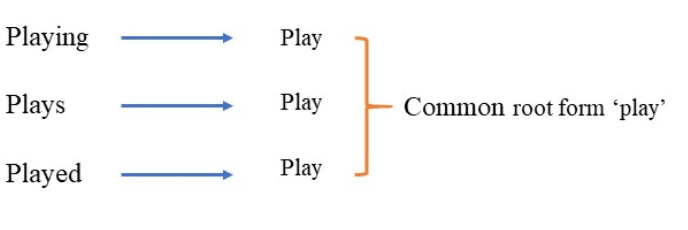

In [18]:
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize,pos_tag
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

def lemmatization(token_text):
  """
  This function performs the lemmatization operations as explained above.
  Input Args:
  token_text: list of tokens.
  Returns:
  lemmatized_tokens: list of lemmatized tokens.
  """
  lemma_tokens = []
  wordnet = WordNetLemmatizer()
  lemmatized_tokens = [wordnet.lemmatize(token, pos = 'v') for token in token_text]

  return lemmatized_tokens




[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
lemmatization("Should we go walking or swimming".split())

['Should', 'we', 'go', 'walk', 'or', 'swim']

### Stemming:

Also a token(word) reduction techniques. This techniques tries to reduce by chopping off a part of the word at the tail end.


### Stemming Vs. Lemmatization.
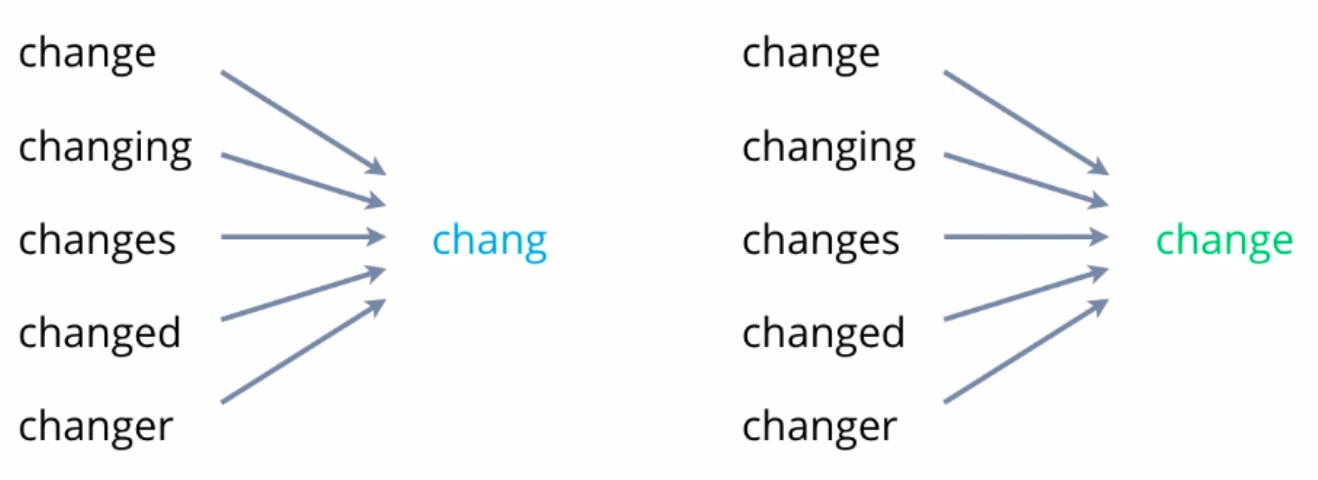

In [20]:
from nltk.stem import PorterStemmer

def stemming(text):
  """
  This function performs stemming operations.
  Input Args:
  token_text: list of tokenize text.
  Returns:
  stemm_tokes: list of stemmed tokens.
  """
  porter = PorterStemmer()
  stemm_tokens = []
  for word in text:
    stemm_tokens.append(porter.stem(word))
  return stemm_tokens

In [21]:
#Test
print("+++++++++++++++++++++++++++++++" "INPUT TOKENS" "++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
token_text_test=['Connects','Connecting','Connections','Connected','Connection','Connectings','Connect']
print(token_text_test)
print("++++++++++++++++++" "LEMMATIZED TOKENS" "+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
lemma_tokens = lemmatization(token_text_test)
print(lemma_tokens)
print("+++++++++++++++++++++" "STEMMED TOKENS" "+++++++++++++++++++++++++++++++++++++")
stemmed_tokens = stemming(token_text_test)
print(stemmed_tokens)


+++++++++++++++++++++++++++++++INPUT TOKENS++++++++++++++++++++++++++++++++++++++++++++++++++++++++
['Connects', 'Connecting', 'Connections', 'Connected', 'Connection', 'Connectings', 'Connect']
++++++++++++++++++LEMMATIZED TOKENS+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
['Connects', 'Connecting', 'Connections', 'Connected', 'Connection', 'Connectings', 'Connect']
+++++++++++++++++++++STEMMED TOKENS+++++++++++++++++++++++++++++++++++++
['connect', 'connect', 'connect', 'connect', 'connect', 'connect', 'connect']


### Lower order:


In [22]:
def lower_order(text):
  """
  This function converts all the text in input text to lower order.
  Input Args:
  token_text : input text.
  Returns:
  small_order_text : text converted to small/lower order.
  """
  small_order_text = text.lower()
  return small_order_text

# Test:
sample_text = "This Is some Normalized TEXT"
sample_small = lower_order(sample_text)
print(sample_small)


this is some normalized text


## Create Input Text Pipeline

We will compile every basic cleaning steps in following one functions and implement with our datasets.

Read data:

In [23]:
data = pd.read_csv("/content/trum_tweet_sentiment_analysis.csv", encoding="ISO-8859-1")
data.head()

,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


In [24]:
data_cleaning = data["text"].dropna()

In [25]:
data_cleaning[0]

'RT @JohnLeguizamo: #trump not draining swamp but our taxpayer dollars on his trips to advertise his properties! @realDonaldTrumpÂ\x85 https://t.co/gFBvUkMX9z'

In [26]:
def text_cleaning_pipeline(dataset, rule = "lemmatize"):
  """
  This...
  """
  # Convert the input to small/lower order.
  data = lower_order(dataset)
  # Remove emojis
  data = remove_emoji(data)
  # Remove all other unwanted characters.
  data = removeunwanted_characters(data)
  # Create tokens.
  tokens = data.split()
  print(tokens)
  # Remove stopwords:
  tokens =remove_stopwords(tokens)
  if rule == "lemmatize":
    tokens = lemmatization(tokens)
  elif rule == "stem":
    tokens =stemming(tokens)
  else:
    print("Pick between lemmatize or stem")


  return " ".join(tokens)



In [27]:
sample = "Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? LMK when you're free cuz I can't go this or next weekend since I'll be swimming!!! #sushiBros #rawFish #🍱"
print(text_cleaning_pipeline(sample))

['hello', 'i', 'still', 'want', 'us', 'to', 'hit', 'that', 'new', 'sushi', 'spot', 'lmk', 'when', 'youre', 'free', 'cuz', 'i', 'cant', 'go', 'this', 'or', 'next', 'weekend', 'since', 'ill', 'be', 'swimming']
hello still want us hit new sushi spot lmk youre free cuz cant go next weekend since ill swim


In [28]:
test = data["text"][0]

In [29]:
print(text_cleaning_pipeline(test))

['rtnot', 'draining', 'swamp', 'but', 'our', 'taxpayer', 'dollars', 'on', 'his', 'trips', 'to', 'advertise', 'his', 'properties', 'httpstcogfbvukmx9z']
rtnot drain swamp taxpayer dollars trip advertise properties httpstcogfbvukmx9z


In [30]:

half_text = df['text'].iloc[:len(df) // 5]  # Take the first half of the text column
cleaned_tokens = half_text.apply(lambda dataset: text_cleaning_pipeline(dataset))


Streaming output truncated to the last 5000 lines.
['httpstcoajelvg2yjx', 'you', 'lie', 'and', 'insult', 'american', 'citizens', 'by', 'thinking', 'that', 'we', 'can', 'possibly', 'believe', 'you']
['rt', 'andrew', 'puzder', 'trumps', 'labor', 'pick', 'admitted', 'that', 'he', 'had', 'employed', 'an', 'undocumented', 'immigrant', 'to', 'clean', 'his', 'house', 'httpstcoz152w9q80r']
['stop', 'broadcasting', 'your', 'blatant', 'ignorance', 'trump', 'just', 'used', 'obama', 'amp', 'dhs', 'existing', 'list', 'the', 'eo', 'has', 'no', 'countries', 'in', 'it', 'httpstcowdqkpapo3q']
['rt', 'rosie', 'odonnell', 'wants', 'to', 'play', 'steve', 'bannon', 'trumps', 'boss', 'on', 'snl', 'to', 'get', 'under', 'the', 'manchilds', 'thin', 'skin', 'retwee', 'httpstcolbsnkqbimd']
['tennessee', 'ceo', 'slated', 'for', 'trumps', 'cabinet', 'under', 'new', 'scrutiny', 'httpstcoxnbf97cqw2']
['its', 'february', '07', '2017', 'at', '0800am', 'somewhere', 'in', 'the', 'world', 'ais', 'telling', 'another', 'li

In [31]:
cleaned_tokens[0]

'rtnot drain swamp taxpayer dollars trip advertise properties httpstcogfbvukmx9z'

In [32]:
print(len(cleaned_tokens))  # Check the length of your features
print(len(df['Sentiment']))  # Check the length of your target labels


370024
1850123


Rough

In [35]:
from sklearn.model_selection import train_test_split

X = cleaned_tokens
y = df['Sentiment'] [:len(cleaned_tokens)] # Trim Y to match the length of x
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(cleaned_tokens)
vectorizer.get_feature_names_out()
print(X.shape)


(925061, 518776)


In [ ]:
print(type(X))
dense_X = X.toarray()  # Convert the sparse matrix to a dense array
print (type(dens_X))

<class 'scipy.sparse._csr.csr_matrix'>


In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)  # Increase max_iter if needed
model.fit(X, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

NameError: name 'X' is not defined

#Actual

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


In [34]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(cleaned_tokens)
y = y = df['Sentiment'] [:len(cleaned_tokens)]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [36]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.96      0.95     49746
           1       0.92      0.87      0.89     24259

    accuracy                           0.93     74005
   macro avg       0.93      0.92      0.92     74005
weighted avg       0.93      0.93      0.93     74005

